In [1]:
import pandas as pd

df2021 = pd.read_excel('Dataset 2021.xlsx')
df2022 = pd.read_excel('Dataset 2022.xlsx')

print("2021 columns:", df2021.columns.tolist())
print("2022 columns:", df2022.columns.tolist())
print("Columns match exactly?", df2021.columns.tolist() == df2022.columns.tolist())

2021 columns: ['Year', 'Crime Type', 'Crime Head', 'Total # FIR', 'Total # Final Report', 'FR Non-Cognizable', 'FR False', 'Mistake of Fact / Law / Civil Dispute', 'True but insufficient evidence', 'Cases Abated', 'Total # Charge Sheeted', 'Total # Cases Disposed Off by Police', '# Cases sent for Trial', 'Cases Disposed Off Without Trial', 'Cases Abated by Court', 'Cases Withdrawn from Prosecution', 'Cases Compounded or Compromised', 'Cases Disposed Off by Plea Bargaining', 'Cases Quashed', 'Cases Convicted', 'Cases Discharged', 'Cases Acquitted', 'Cases Where Trials Were Completed', 'Total # Cases Disposed Off by Courts']
2022 columns: ['Year', 'Crime Type', 'Crime Head', 'Total # FIR', 'Total # Final Report', 'FR Non-Cognizable', 'FR False', 'Mistake of Fact / Law / Civil Dispute', 'True but insufficient evidence', 'Cases Abated', 'Total # Charge Sheeted', 'Total # Cases Disposed Off by Police', '# Cases sent for Trial', 'Cases Disposed Off Without Trial', 'Cases Abated by Court', 'C

In [2]:
heads_2021 = set(df2021['Crime Head'])
heads_2022 = set(df2022['Crime Head'])

print("Same Crime Heads in both years?", heads_2021 == heads_2022)
print("Difference if any:", heads_2021.symmetric_difference(heads_2022))

Same Crime Heads in both years? True
Difference if any: set()


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Datasets
df2021 = pd.read_excel('Dataset 2021.xlsx')
df2022 = pd.read_excel('Dataset 2022.xlsx')

# Merge 2021 and 2022 on Crime Head and Crime Type
df_merged = pd.merge(
    df2021, df2022,
    on=['Crime Head', 'Crime Type'],
    suffixes=('_2021', '_2022')
)

# Calculate Key Rates
df_merged['CS_Rate_2021'] = (df_merged['Total # Charge Sheeted_2021'] / df_merged['Total # FIR_2021'] * 100).round(2)
df_merged['CS_Rate_2022'] = (df_merged['Total # Charge Sheeted_2022'] / df_merged['Total # FIR_2022'] * 100).round(2)

df_merged['Conviction_Rate_2021'] = (df_merged['Cases Convicted_2021'] / df_merged['Total # Cases Disposed Off by Courts_2021'] * 100).round(2)
df_merged['Conviction_Rate_2022'] = (df_merged['Cases Convicted_2022'] / df_merged['Total # Cases Disposed Off by Courts_2022'] * 100).round(2)

# YoY Differences
df_merged['FIR_YoY_Growth (%)'] = ((df_merged['Total # FIR_2022'] - df_merged['Total # FIR_2021']) / df_merged['Total # FIR_2021'] * 100).round(2)
df_merged['CS_Rate_Diff (%p)'] = (df_merged['CS_Rate_2022'] - df_merged['CS_Rate_2021']).round(2)
df_merged['Conviction_Rate_Diff (%p)'] = (df_merged['Conviction_Rate_2022'] - df_merged['Conviction_Rate_2021']).round(2)

# Display Key Comparative Columns
comp_summary = df_merged[[
    'Crime Head', 'Crime Type',
    'Total # FIR_2021', 'Total # FIR_2022', 'FIR_YoY_Growth (%)',
    'CS_Rate_2021', 'CS_Rate_2022', 'CS_Rate_Diff (%p)',
    'Conviction_Rate_2021', 'Conviction_Rate_2022', 'Conviction_Rate_Diff (%p)'
]].sort_values(by='Total # FIR_2022', ascending=False)

print(comp_summary.to_string(index=False))

                                              Crime Head Crime Type  Total # FIR_2021  Total # FIR_2022  FIR_YoY_Growth (%)  CS_Rate_2021  CS_Rate_2022  CS_Rate_Diff (%p)  Conviction_Rate_2021  Conviction_Rate_2022  Conviction_Rate_Diff (%p)
                                         Prohibition Act        SLL            678998            704281                3.72         95.32         98.21               2.89                 61.01                 66.70                       5.69
                                                   Theft        IPC            586649            652731               11.26         27.18         29.34               2.16                 29.15                 33.72                       4.57
                                                    Hurt        IPC            585774            627676                7.15         89.97         90.82               0.85                 27.79                 27.06                      -0.73
                              Ra

=== Crime Statistics Comparison Summary (2021 vs 2022) ===
                                              Crime Head Crime Type  Total # FIR_2021  Total # FIR_2022  FIR_YoY_Growth (%)  CS_Rate_2021  CS_Rate_2022  CS_Rate_Diff (%p)  Conv_Rate_2021  Conv_Rate_2022  Conv_Rate_Diff (%p)
                                         Prohibition Act        SLL            678998            704281                3.72         95.32         98.21               2.89           61.01           66.70                 5.69
                                                   Theft        IPC            586649            652731               11.26         27.18         29.34               2.16           29.15           33.72                 4.57
                                                    Hurt        IPC            585774            627676                7.15         89.97         90.82               0.85           27.79           27.06                -0.73
                              Rash Driving on

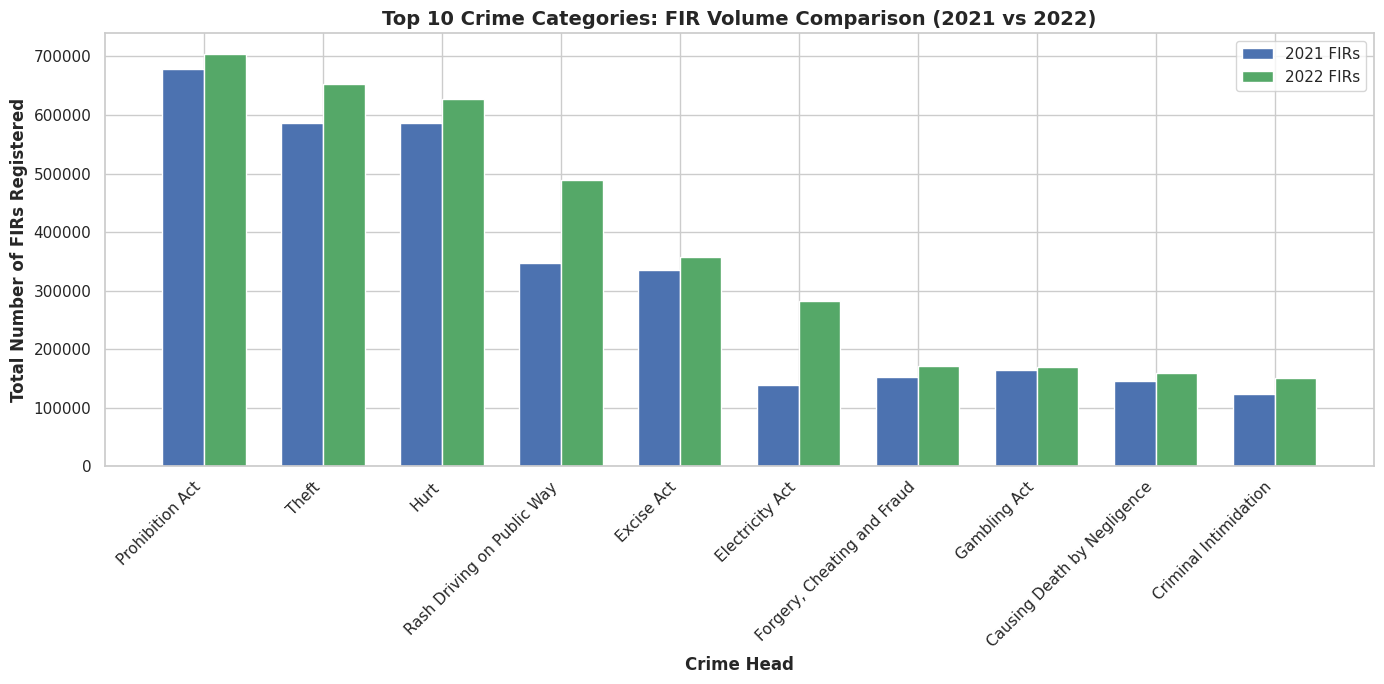

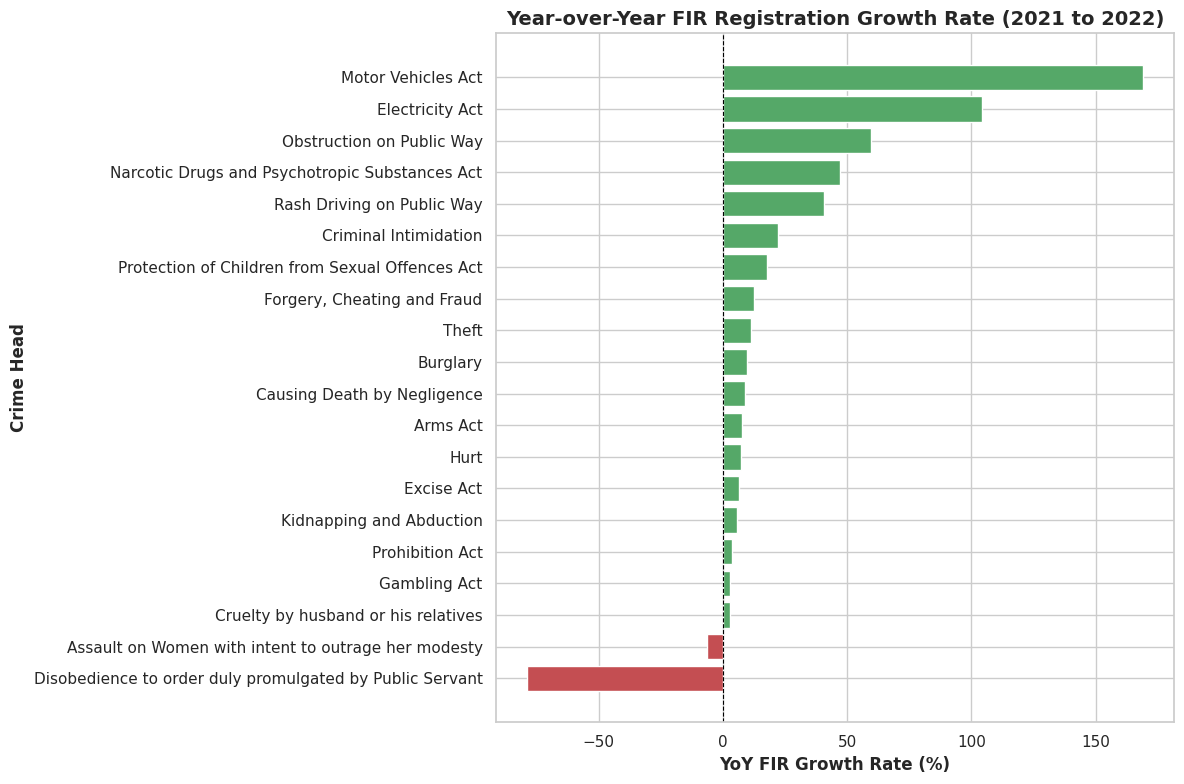

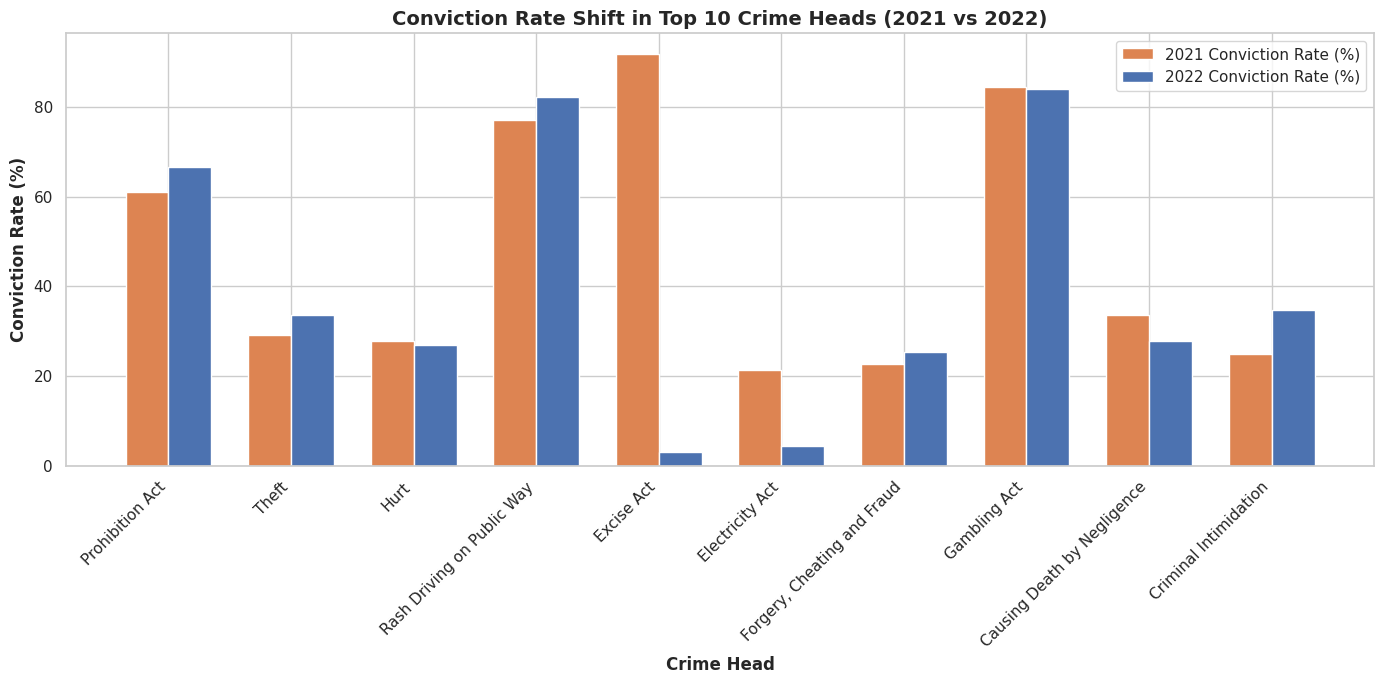

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load 2021 and 2022 Datasets
df_2021 = pd.read_excel('Dataset 2021.xlsx')
df_2022 = pd.read_excel('Dataset 2022.xlsx')

# 2. Merge Datasets on Primary Key Identifiers
merged_df = pd.merge(
    df_2021,
    df_2022,
    on=['Crime Head', 'Crime Type'],
    suffixes=('_2021', '_2022')
)

# 3. Calculate Key Performance Indicators (KPIs)
# Charge-Sheet Rate (%)
merged_df['CS_Rate_2021'] = (merged_df['Total # Charge Sheeted_2021'] / merged_df['Total # FIR_2021'] * 100).round(2)
merged_df['CS_Rate_2022'] = (merged_df['Total # Charge Sheeted_2022'] / merged_df['Total # FIR_2022'] * 100).round(2)
merged_df['CS_Rate_Diff (%p)'] = (merged_df['CS_Rate_2022'] - merged_df['CS_Rate_2021']).round(2)

# Conviction Rate (%)
merged_df['Conv_Rate_2021'] = (merged_df['Cases Convicted_2021'] / merged_df['Total # Cases Disposed Off by Courts_2021'] * 100).round(2)
merged_df['Conv_Rate_2022'] = (merged_df['Cases Convicted_2022'] / merged_df['Total # Cases Disposed Off by Courts_2022'] * 100).round(2)
merged_df['Conv_Rate_Diff (%p)'] = (merged_df['Conv_Rate_2022'] - merged_df['Conv_Rate_2021']).round(2)

# Year-over-Year (YoY) Percentage Growth
merged_df['FIR_YoY_Growth (%)'] = (((merged_df['Total # FIR_2022'] - merged_df['Total # FIR_2021']) / merged_df['Total # FIR_2021']) * 100).round(2)
merged_df['CS_YoY_Growth (%)'] = (((merged_df['Total # Charge Sheeted_2022'] - merged_df['Total # Charge Sheeted_2021']) / merged_df['Total # Charge Sheeted_2021']) * 100).round(2)

# 4. Generate Core Summary Table
comp_summary = merged_df[[
    'Crime Head', 'Crime Type',
    'Total # FIR_2021', 'Total # FIR_2022', 'FIR_YoY_Growth (%)',
    'CS_Rate_2021', 'CS_Rate_2022', 'CS_Rate_Diff (%p)',
    'Conv_Rate_2021', 'Conv_Rate_2022', 'Conv_Rate_Diff (%p)'
]].sort_values(by='Total # FIR_2022', ascending=False)

# Display Summary Table in Console
print("=== Crime Statistics Comparison Summary (2021 vs 2022) ===")
print(comp_summary.to_string(index=False))

# Export Full Comparative Analysis to Excel
comp_summary.to_excel('Crime_Comparison_2021_2022_Summary.xlsx', index=False)


# Visual 1: Top 10 Crime Heads Volume Comparison (Grouped Bar Chart)
plt.figure(figsize=(14, 7))
top10 = comp_summary.head(10)
x = np.arange(len(top10))
width = 0.35

plt.bar(x - width/2, top10['Total # FIR_2021'], width, label='2021 FIRs', color='#4c72b0')
plt.bar(x + width/2, top10['Total # FIR_2022'], width, label='2022 FIRs', color='#55a868')

plt.xlabel('Crime Head', fontweight='bold')
plt.ylabel('Total Number of FIRs Registered', fontweight='bold')
plt.title('Top 10 Crime Categories: FIR Volume Comparison (2021 vs 2022)', fontsize=14, fontweight='bold')
plt.xticks(x, top10['Crime Head'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Visual 2: YoY Percentage Growth in Registered FIRs (Diverging Bar Chart)
plt.figure(figsize=(12, 8))
yoy_sorted = merged_df.sort_values(by='FIR_YoY_Growth (%)', ascending=True)

colors = ['#c44e52' if val < 0 else '#55a868' for val in yoy_sorted['FIR_YoY_Growth (%)']]
plt.barh(yoy_sorted['Crime Head'], yoy_sorted['FIR_YoY_Growth (%)'], color=colors)

plt.xlabel('YoY FIR Growth Rate (%)', fontweight='bold')
plt.ylabel('Crime Head', fontweight='bold')
plt.title('Year-over-Year FIR Registration Growth Rate (2021 to 2022)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# Visual 3: Conviction Rate Shift Comparison
plt.figure(figsize=(14, 7))
top_conv = comp_summary.head(10)
x = np.arange(len(top_conv))

plt.bar(x - width/2, top_conv['Conv_Rate_2021'], width, label='2021 Conviction Rate (%)', color='#dd8452')
plt.bar(x + width/2, top_conv['Conv_Rate_2022'], width, label='2022 Conviction Rate (%)', color='#4c72b0')

plt.xlabel('Crime Head', fontweight='bold')
plt.ylabel('Conviction Rate (%)', fontweight='bold')
plt.title('Conviction Rate Shift in Top 10 Crime Heads (2021 vs 2022)', fontsize=14, fontweight='bold')
plt.xticks(x, top_conv['Crime Head'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# **Key Insights:**

**Highest Case Volume Spike:**

 Motor Vehicles Act offenses (+169.17%) and Electricity Act violations (+104.10%) showed the largest relative surge in FIR registrations from 2021 to 2022.

**Sharpest Volume Drop:**

Disobedience to order duly promulgated by Public Servant declined by -79.09% (falling from 322,115 cases in 2021 to 67,350 in 2022), reflecting post-COVID lockdown normalization.

**Conviction Rate Shift: **

Convictions for Criminal Intimidation grew (+9.91 percentage points), while judicial conviction rates under the Electricity Act (-17.12 percentage points) and Arms Act (-17.32 percentage points) experienced noticeable drops.